# Question 1

To be able to use this model, we need to know the name of the input and output nodes.

What's the name of the output:

output

In [12]:
import onnxruntime as ort

In [14]:
onnx_model_path = "homework_9/hair_classifier_v1.onnx"
session = ort.InferenceSession(onnx_model_path, providers=["CPUExecutionProvider"])
# 取出模型的输入、输出信息列表
inputs = session.get_inputs() 
outputs = session.get_outputs() 

for i in inputs:
    print(i.name, i.shape, i.type)


for o in outputs:
    print(o.name, o.shape, o.type)


# 取第一个输入的名字、第一个输出的名字。后面推理时要按这些名字传数据、取结果。
input_name = inputs[0].name
output_name = outputs[0].name

input ['s77', 3, 200, 200] tensor(float)
output ['s77', 1] tensor(float)


In [3]:
# 从网络下载一张图片，并把它调整到模型需要的输入尺寸。它是图像预处理流水线的一部分，通常用在推理之前
import numpy as np
from io import BytesIO
from urllib import request

from PIL import Image

def download_image(url):
    with request.urlopen(url) as resp:
        buffer = resp.read()
    stream = BytesIO(buffer)
    img = Image.open(stream)
    return img


def prepare_image(img, target_size):
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img = img.resize(target_size, Image.NEAREST)
    return img

# Question 2: Target size

In [ ]:
Let's download and resize this image:

https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg

Based on the previous homework, what should be the target size for the image?

200x200

# Question 3

In [19]:
from tensorflow.keras.applications.xception import preprocess_input
url = 'https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg'
img = download_image(url)
img = prepare_image(img, (200, 200)) 
x = np.array(img, dtype=np.float32)
x = preprocess_input(x)
print(x[0, 0, 0])  # 第一个像素的 R 通道

-0.52156866


# Question 4

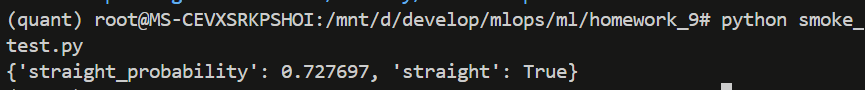

In [ ]:
# 创建
docker build --platform linux/amd64 --provenance=false --no-cache -t mlzoomcamp-2026-serverless:latest .
docker run --rm -p 9000:8080 mlzoomcamp-2026-serverless

In [ ]:
# 在开发环境终端中，执行以下代码，测试容器
curl -s \
  -XPOST 'http://localhost:9000/2015-03-31/functions/function/invocations' \
  -H 'Content-Type: application/json' \
  -d '{"image_url":"https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg"}'
# 下图是测试的截图

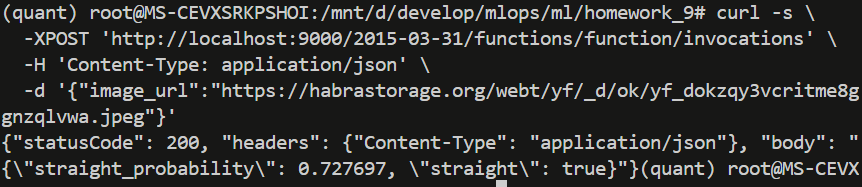

#  Question 5

In [ ]:
public.ecr.aws/lambda/python:3.13

# Question 6

In [ ]:
0.728

# Optional AWS deployment
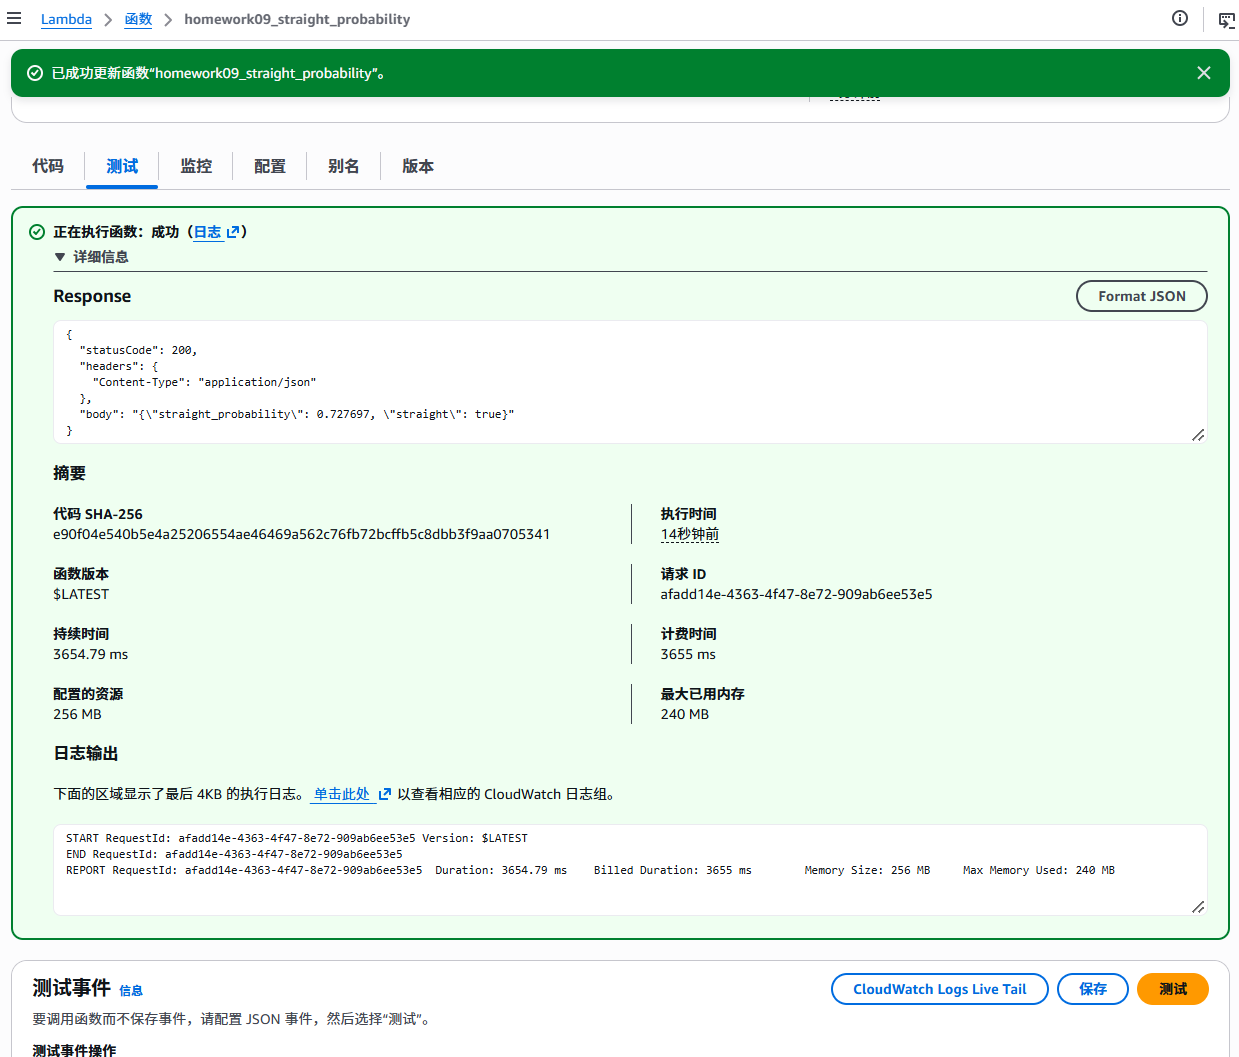